In [105]:
## Imports:

from datetime import datetime
from datetime import timedelta
import numpy as np
import random

# Stone Soup Imports:
from stonesoup.types.state import State, GaussianState
from stonesoup.types.array import StateVector, CovarianceMatrix
from stonesoup.models.transition.linear import (
    CombinedLinearGaussianTransitionModel, ConstantVelocity)
from stonesoup.models.measurement.nonlinear import CartesianToElevationBearingRange
from stonesoup.deleter.time import UpdateTimeStepsDeleter
from stonesoup.tracker.simple import MultiTargetMixtureTracker

In [106]:
## Params setting

start_time = datetime.now()
np.random.seed(73)
random.seed(567)
initial_number_targets = 4

In [107]:
## Stationary Platform (0,0,0)

platform_state_vector = StateVector([[0],[0],[0]])
position_mapping = (0, 1, 2) # 0-->x; 1-->y; 2-->z of the SS StateVector
platform_state = State(platform_state_vector, start_time)
from stonesoup.platform.base import FixedPlatform
platform = FixedPlatform(
    states=platform_state,
    position_mapping=position_mapping
)

In [108]:
## Radar params and creation

from stonesoup.sensor.radar.radar import RadarElevationBearingRange
from stonesoup.models.clutter import ClutterModel  # To generate clutter directly from the sensor

# Covariance matrix
noise_covar = CovarianceMatrix(np.array(np.diag([np.deg2rad(0.15)**2,np.deg2rad(0.15)**2,25**2])))
radar_mapping = (0, 2, 4)

# Clutter
params = ((-10000, 10000),  # clutter min x and max x
          (-10000, 10000),  # clutter min y and max y
          (8000, 10000))  # clutter min z and max z
clutter_model = ClutterModel(
     clutter_rate=0.5,
     distribution=np.random.default_rng().uniform,
     dist_params=params
)

radar = RadarElevationBearingRange(
    ndim_state=6,
    position_mapping=radar_mapping,
    noise_covar=noise_covar,
    clutter_model=clutter_model
)

platform.add_sensor(radar)

In [109]:
## Simulation

transition_model = CombinedLinearGaussianTransitionModel([ConstantVelocity(0.5), ConstantVelocity(0.5), ConstantVelocity(0.1)])

initial_target_state = GaussianState(
    state_vector=StateVector([[0], [0], [0], [0], [9000], [0]]),
    covar=CovarianceMatrix(np.diag([2000, 50, 2000, 50, 100, 1]))
)

from stonesoup.simulator.simple import MultiTargetGroundTruthSimulator
groundtruth_sim = MultiTargetGroundTruthSimulator(
    transition_model=transition_model,  # Target transition model
    initial_state=initial_target_state,  # Initial state for targets
    timestep=timedelta(seconds=1),  # Time between measurements
    initial_number_targets=initial_number_targets,  # Start with tot targets at t0
    number_steps=200,  # 2 minutes
    birth_rate= 0.05,  # 5% chance of a new target being born every second
    death_probability=0.02  # 2% chance of a target being killed
)

from stonesoup.simulator.platform import PlatformDetectionSimulator

sim = PlatformDetectionSimulator(
    groundtruth=groundtruth_sim,
    platforms=[platform]
)

In [110]:
## Tracking Algorithm

# Kalman Predictor
from stonesoup.predictor.kalman import KalmanPredictor
predictor = KalmanPredictor(transition_model)
meas_covar = np.diag([np.deg2rad(0.5), np.deg2rad(0.15), 25])
meas_covar_trk = CovarianceMatrix(1.0*np.power(meas_covar, 2))
meas_model = CartesianToElevationBearingRange(
    ndim_state=6,
    mapping=(0, 2, 4),
    noise_covar=meas_covar_trk
)

from stonesoup.updater.kalman import ExtendedKalmanUpdater
updater = ExtendedKalmanUpdater(measurement_model=meas_model)

In [111]:
## Hypothesiser

from stonesoup.hypothesiser.probability import PDAHypothesiser
Pd = 0.95  # 95%
hypothesiser = PDAHypothesiser(predictor=predictor,
                               updater=updater,
                               clutter_spatial_density=1e-9,
                               prob_detect=Pd)

from stonesoup.dataassociator.probability import JPDA
data_associator = JPDA(hypothesiser=hypothesiser)
deleter = UpdateTimeStepsDeleter(time_steps_since_update=3)

In [112]:
## Initiator

from stonesoup.initiator.simple import MultiMeasurementInitiator
from stonesoup.dataassociator.neighbour import NearestNeighbour

min_detections = 3  # number of detections required to begin a track
initiator_prior_state = GaussianState(
    state_vector=np.array([[0], [0], [0], [0], [0], [0]]),
    covar=np.diag([0, 50, 0, 50, 0, 50])**2
)

initiator_meas_model = CartesianToElevationBearingRange(
    ndim_state=6,
    mapping=np.array([0, 2, 4]),
    noise_covar=noise_covar
)

initiator = MultiMeasurementInitiator(
    prior_state=initiator_prior_state,
    measurement_model=initiator_meas_model,
    deleter=deleter,
    data_associator=NearestNeighbour(hypothesiser),
    updater=updater,
    min_points=min_detections,
    updates_only=True
)

# JDA creation

JPDA_tracker = MultiTargetMixtureTracker(
    initiator=initiator,
    deleter=deleter,
    detector=sim,
    data_associator=data_associator,
    updater=updater
)

In [113]:
## Run the Simulation and Tracker

# Create lists to hold the information we want to plot later
tracks_plot = set()
tracks_id = set()
groundtruth_plot = set()
detections_plot = set()

# Run the simulation and tracker
for time, ctracks in JPDA_tracker:
    print(time)  # allows us to see the progress of the tracking simulation

    for track in ctracks:
        tracks_plot.add(track)
    for truth in groundtruth_sim.current[1]:
        groundtruth_plot.add(truth)
    for detection in sim.detections:
        detections_plot.add(detection)

        

2026-04-27 09:11:56.909489
2026-04-27 09:11:57.909489
2026-04-27 09:11:58.909489
2026-04-27 09:11:59.909489
2026-04-27 09:12:00.909489
2026-04-27 09:12:01.909489
2026-04-27 09:12:02.909489
2026-04-27 09:12:03.909489
2026-04-27 09:12:04.909489
2026-04-27 09:12:05.909489
2026-04-27 09:12:06.909489
2026-04-27 09:12:07.909489
2026-04-27 09:12:08.909489
2026-04-27 09:12:09.909489
2026-04-27 09:12:10.909489
2026-04-27 09:12:11.909489
2026-04-27 09:12:12.909489
2026-04-27 09:12:13.909489
2026-04-27 09:12:14.909489
2026-04-27 09:12:15.909489
2026-04-27 09:12:16.909489
2026-04-27 09:12:17.909489
2026-04-27 09:12:18.909489
2026-04-27 09:12:19.909489
2026-04-27 09:12:20.909489
2026-04-27 09:12:21.909489
2026-04-27 09:12:22.909489
2026-04-27 09:12:23.909489
2026-04-27 09:12:24.909489
2026-04-27 09:12:25.909489
2026-04-27 09:12:26.909489
2026-04-27 09:12:27.909489
2026-04-27 09:12:28.909489
2026-04-27 09:12:29.909489
2026-04-27 09:12:30.909489
2026-04-27 09:12:31.909489
2026-04-27 09:12:32.909489
2

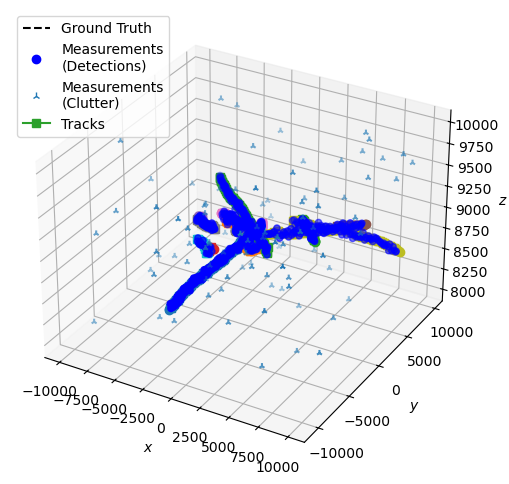

In [114]:
## Plots

from stonesoup.plotter import Plotter, Dimension
plotter = Plotter(Dimension.THREE)
plotter.plot_ground_truths(groundtruth_plot, [0, 2, 4])
plotter.plot_measurements(detections_plot, [0, 2, 4])
_ = plotter.plot_tracks(tracks_plot, [0, 2, 4], uncertainty=False, err_freq=5)

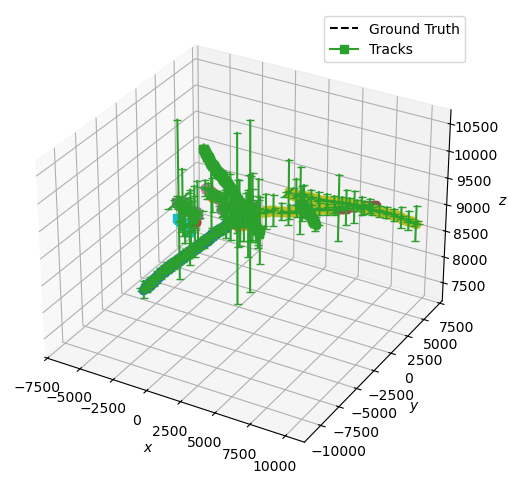

In [115]:
plotter2 = Plotter(Dimension.THREE)
plotter2.plot_ground_truths(groundtruth_plot, [0, 2, 4])
_ = plotter2.plot_tracks(tracks_plot, [0, 2, 4], uncertainty=True, err_freq=5)

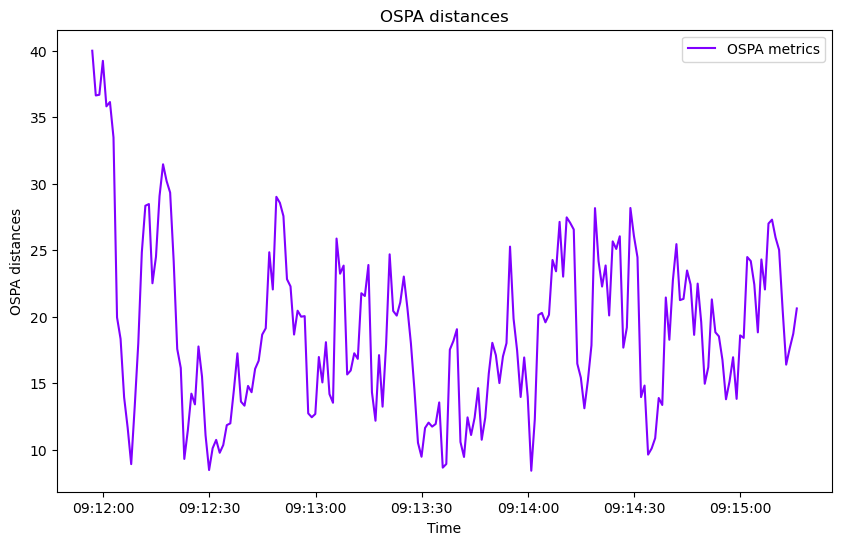

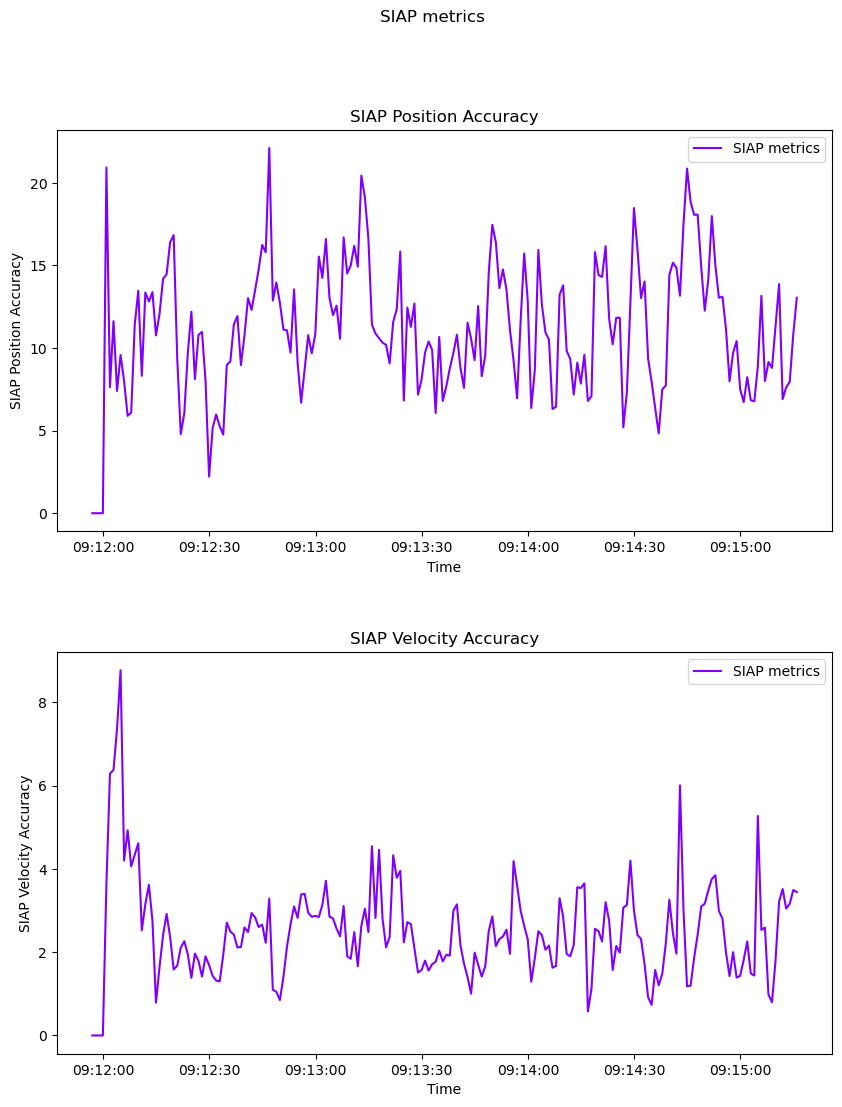

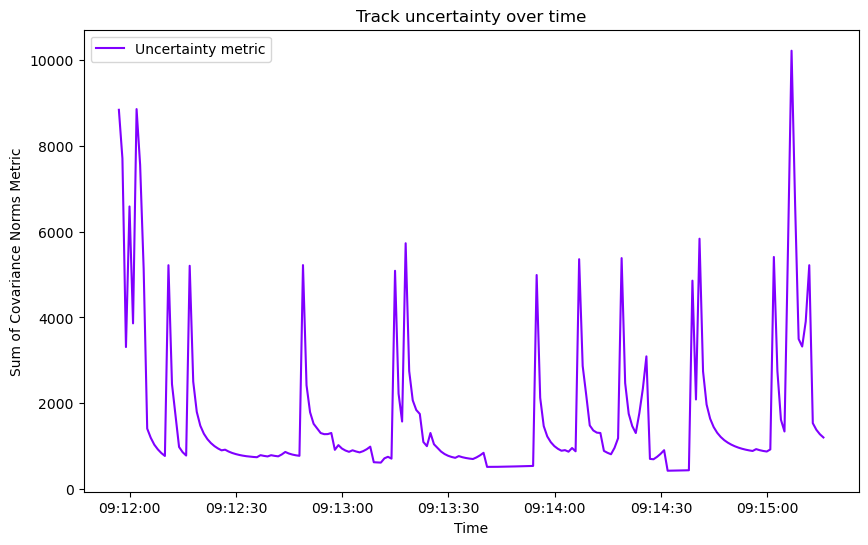

In [116]:
# OSPA metric
from stonesoup.metricgenerator.ospametric import OSPAMetric
ospa_generator = OSPAMetric(c=40, p=1,
                            generator_name='OSPA metrics',
                            tracks_key='tracks',
                            truths_key='truths'
                            )

# SIAP metrics
from stonesoup.metricgenerator.tracktotruthmetrics import SIAPMetrics
from stonesoup.measures import Euclidean
SIAPpos_measure = Euclidean(mapping=np.array([0, 2]))
SIAPvel_measure = Euclidean(mapping=np.array([1, 3]))
siap_generator = SIAPMetrics(
    position_measure=SIAPpos_measure,
    velocity_measure=SIAPvel_measure,
    generator_name='SIAP metrics',
    tracks_key='tracks',
    truths_key='truths'
)

# Uncertainty metric
from stonesoup.metricgenerator.uncertaintymetric import \
    SumofCovarianceNormsMetric
uncertainty_generator = SumofCovarianceNormsMetric(generator_name='Uncertainty metric',
                                                   tracks_key='tracks')
from stonesoup.dataassociator.tracktotrack import TrackToTruth
associator = TrackToTruth(association_threshold=30)

from stonesoup.metricgenerator.manager import MultiManager
metric_manager = MultiManager(
    [ospa_generator, siap_generator, uncertainty_generator],
    associator=associator
)
metric_manager.add_data({'truths': groundtruth_plot, 'tracks': tracks_plot})
metrics = metric_manager.generate_metrics()
from stonesoup.plotter import MetricPlotter

fig1 = MetricPlotter()
fig1.plot_metrics(metrics, generator_names=['OSPA metrics'])
fig2 = MetricPlotter()
fig2.plot_metrics(metrics, metric_names=['SIAP Position Accuracy at times',
                                         'SIAP Velocity Accuracy at times'])
fig2.set_fig_title('SIAP metrics')
fig3 = MetricPlotter()
fig3.plot_metrics(metrics, generator_names=['Uncertainty metric'])
fig3.set_ax_title(['Track uncertainty over time'])